# Video: Visualizing Bias and Variance Tradeoffs

In this video, we will look at how bias and variance of a modeling process change with the hyperparameters of the process.

[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week14/video_visualizing_bias_and_variance_tradeoffs.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week14/video_visualizing_bias_and_variance_tradeoffs.ipynb)



Script: (faculty on screen)
* The bias and variance of a process are often associated with a fuzzy notion of flexibility in the model, and sometimes this is quantified by the number of model parameters.
* This intuition is approximately correct, but not quite right.
* In this video, we will first look at polynomial regression and see the bias and variance changes as the polynomial degree changes.
* When the polynomial degree increases, the bias will decrease and the variance will increase, matching the common intuition.
* Then we will look at the impact of Bayesian priors and see similar tradeoffs between bias and variance without changing the number of parameters.

## A Neat Bias-Variance Tradeoff

![](https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Bias_and_variance_contributing_to_total_error.svg/3840px-Bias_and_variance_contributing_to_total_error.svg.png)

Source: https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff

Script:
* A typical way to think of bias-variance tradeoffs is to say that bias is high when the model is simple, and low when the model is complex.
* Since bias is a signed quantity, we will square it which will make it more comparable to variance too.
* That gives us the red curve in this figure.
* In comparison, variance is low for simple models and increases with more complex models.
* Typically, more complex models are more flexible, so they can adapt more to the data set, but that results in increasing variation in predictions and more variance.
* To manage the tradeoffs, we will add these two quantities for a measure of toal error, and then pick the complexity level to minimize the total error.

## Synthetic Sample Data


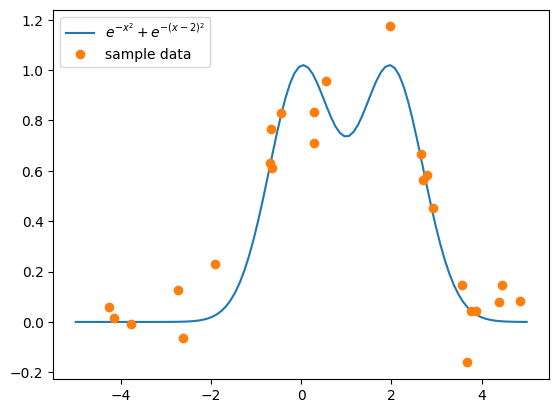

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

formula = "e^{-x^2} + e^{-(x-2)^2}"

def f(x):
    return np.exp(-x**2) + np.exp(-(x - 2)**2)

def sample(n):
    xs = np.random.uniform(low=-5, high=5, size=n)
    ys = f(xs) + np.random.normal(scale=0.1, size=n)
    return xs, ys

xs_truth = np.linspace(-5, 5, 100)
ys_truth = f(xs_truth)

np.random.seed(42_14_1)
xs_train, ys_train = sample(25)

plt.plot(xs_truth, ys_truth, label=f"${formula}$")
plt.plot(xs_train, ys_train, 'o', label=f"sample data")

plt.legend()
plt.show()

Script:
* We will use the same synthetic distribution to look at bias and variance again.
* This function is complicated enough we will see more complicated bias and variance plots, both when looking at individual inputs and when plotting by complexity measures.

## Sample Linear Models


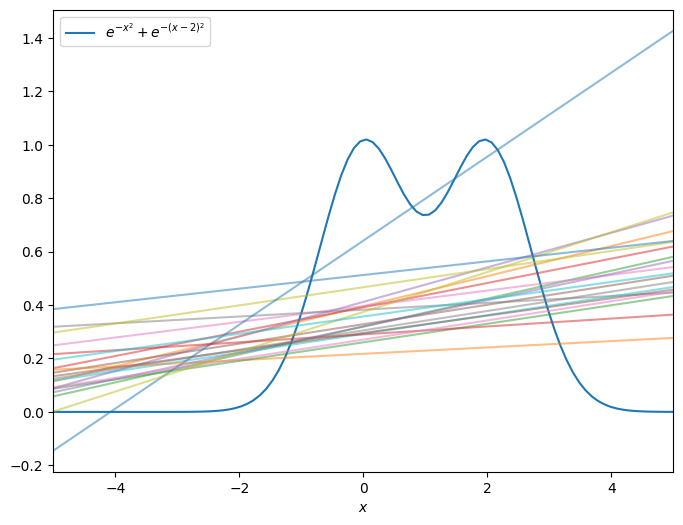

In [ ]:
from sklearn.linear_model import LinearRegression

n_models = 20

np.random.seed(42_14_2)
sample_data_sets = [sample(25) for _ in range(n_models)]

plt.figure(figsize=(8, 6))

plt.plot(xs_truth, ys_truth, label=f"${formula}$")

all_ys_model_pred = []

for i in range(n_models):
    xs_model, ys_model = sample_data_sets[i]
    model = LinearRegression()
    model.fit(xs_model.reshape(-1, 1), ys_model)
    ys_model_pred = model.predict(xs_truth.reshape(-1, 1))
    all_ys_model_pred.append(ys_model_pred)
    plt.plot(xs_truth, ys_model_pred, alpha=0.5)

all_ys_model_pred = np.asarray(all_ys_model_pred)

plt.legend()
plt.xlabel("$x$")
plt.xlim(xs_truth.min(), xs_truth.max())

plt.show()

Script:
* Here are some sample linear models.
* As we saw before, they do not fit the ground truth well because of the elevated values in the middle.

## Bias and Variance of Linear Functions (d=1)


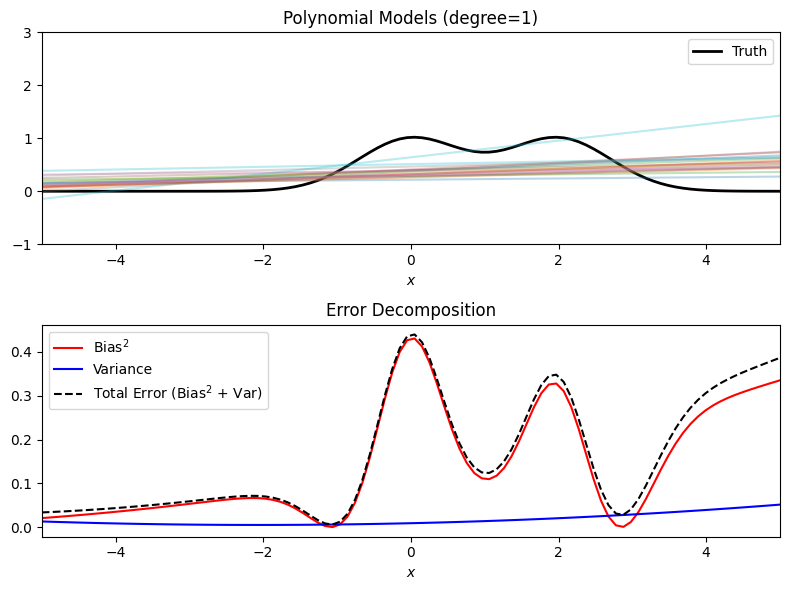

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def show_bias_variance_by_degree(d):
    all_preds = []
    plt.figure(figsize=(8, 6))

    # 1. Fit models and collect predictions
    for i in range(n_models):
        xs_model, ys_model = sample_data_sets[i]
        model = make_pipeline(PolynomialFeatures(d), LinearRegression())
        model.fit(xs_model.reshape(-1, 1), ys_model)
        ys_pred = model.predict(xs_truth.reshape(-1, 1))
        all_preds.append(ys_pred)

    all_preds = np.array(all_preds)

    # 2. Calculate Bias and Variance
    avg_pred = np.mean(all_preds, axis=0)
    bias_sq = (avg_pred - ys_truth)**2
    variance = np.var(all_preds, axis=0)
    total_error = bias_sq + variance

    # Subplot 1: Models
    plt.subplot(2, 1, 1)
    plt.plot(xs_truth, ys_truth, label='Truth', color='black', linewidth=2)
    for i in range(n_models):
        plt.plot(xs_truth, all_preds[i], alpha=0.3)
    plt.title(f"Polynomial Models (degree={d})")
    plt.legend()
    plt.xlabel("$x$")
    plt.xlim(xs_truth.min(), xs_truth.max())
    plt.ylim(-1, 3)

    # Subplot 2: Bias^2, Variance, and Total
    plt.subplot(2, 1, 2)
    plt.plot(xs_truth, bias_sq, color='red', label='Bias$^2$')
    plt.plot(xs_truth, variance, color='blue', label='Variance')
    plt.plot(xs_truth, total_error, color='black', linestyle='--', label='Total Error (Bias$^2$ + Var)')
    plt.title("Error Decomposition")
    plt.legend()
    plt.xlabel("$x$")
    plt.xlim(xs_truth.min(), xs_truth.max())

    # Use log scale if variance is very high (common in degree 10)
    if d >= 10:
        plt.yscale('log')

    plt.tight_layout()
    plt.show()

show_bias_variance_by_degree(1)

Script:
* Here's another view.
* The top chart is the same, and the bottom chart shows the error decomposition by input vlue.
* We can see that some parts of the curve are harder for the linear models to handle, particularly the higher values.


## Bias and Variance of Quadratic Functions (d=2)


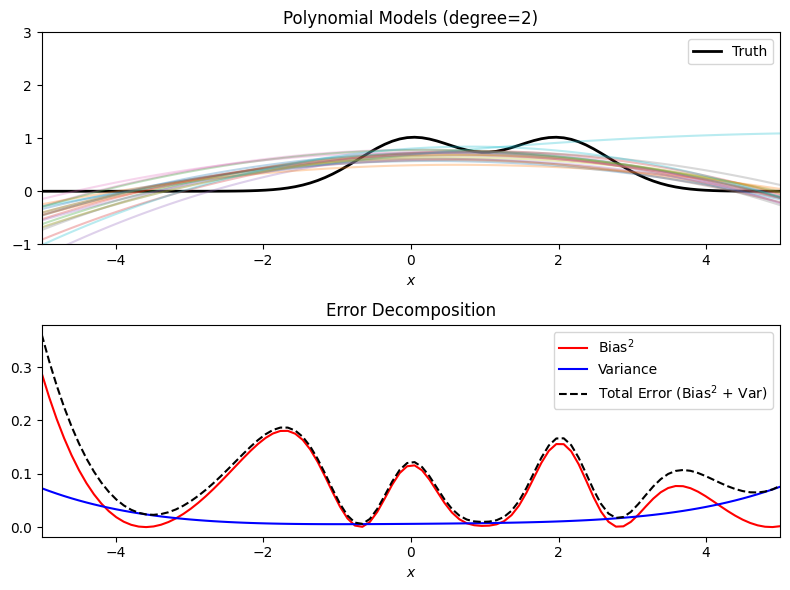

In [ ]:
show_bias_variance_by_degree(2)

Script:
* If we increase the degree to two and use quadratic functions, the model is a better fit for higher values.
* The bias is much lower in this case.

## Bias and Variance of Cubic Functions (d=3)


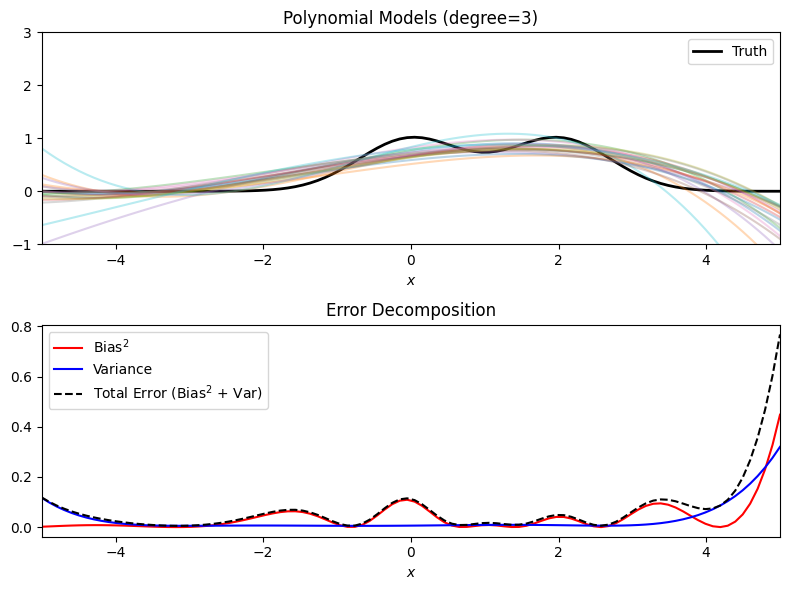

In [ ]:
show_bias_variance_by_degree(3)

Script:
* If we increase the degree to 3, the bias drops even further for most of the range, but both the bias and variance are picking up for inputs in the range 4 to 5.
* We can see that in the models up top.
* Their predictions are all spread out on both ends despite being close in the middle.

## Bias and Variance of Degree 10 Polynomial (d=10)


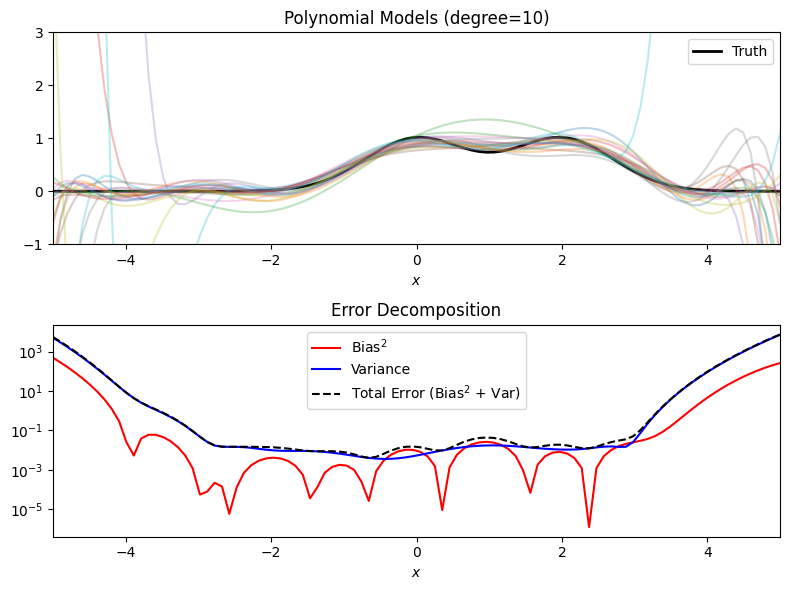

In [ ]:
show_bias_variance_by_degree(10)

Script:
* When the degree is increased to ten, the effect is stronger on both sides.
* Again, the outputs are alright for the middle inputs, but the outputs are erratic past the training data.
* This is classic overfitting.

## Bias and Variance by Polynomial Degree


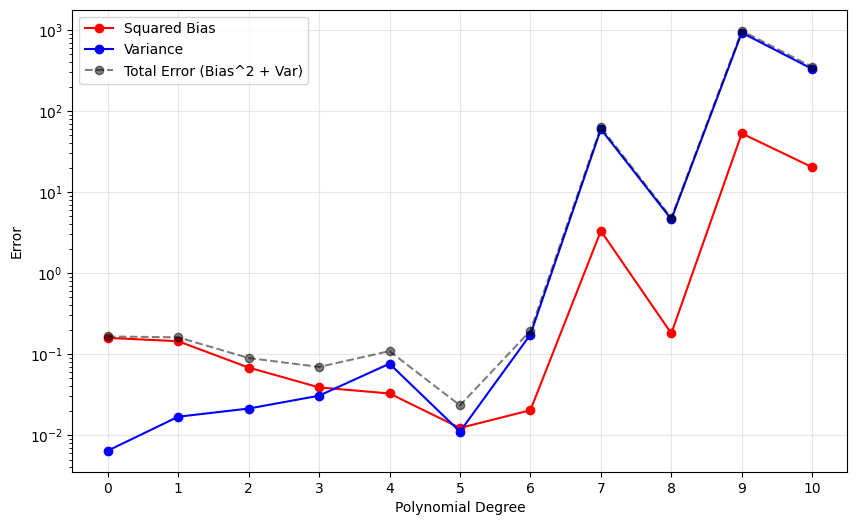

In [ ]:
degrees = np.arange(0, 11)

avg_sq_biases = []
avg_variances = []

for d in degrees:
    all_preds = []
    for i in range(n_models):
        xs_model, ys_model = sample_data_sets[i]
        model = make_pipeline(PolynomialFeatures(d), LinearRegression())
        model.fit(xs_model.reshape(-1, 1), ys_model)
        ys_pred = model.predict(xs_truth.reshape(-1, 1))
        all_preds.append(ys_pred)

    all_preds = np.array(all_preds)

    # Calculate bias and variance at every point x
    avg_pred = np.mean(all_preds, axis=0)
    bias_sq = (avg_pred - ys_truth)**2
    variance = np.var(all_preds, axis=0)

    # Average over the range of x to get a single number for this degree
    avg_sq_biases.append(np.mean(bias_sq))
    avg_variances.append(np.mean(variance))

plt.figure(figsize=(10, 6))
plt.plot(degrees, avg_sq_biases, 'o-', label='Squared Bias', color='red')
plt.plot(degrees, avg_variances, 'o-', label='Variance', color='blue')
plt.plot(degrees, np.array(avg_sq_biases) + np.array(avg_variances), 'o--', label='Total Error (Bias^2 + Var)', color='black', alpha=0.5)

plt.xlabel('Polynomial Degree')
plt.ylabel('Error')
plt.xticks(degrees)
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log') # Log scale often helps see the trade-off more clearly when variance explodes
plt.show()

Script:
* Let's look at the bias and variance as functions of the polynomial degree.
* This picture is more complicated than the idealized tradeoffs we saw at the beginning.
* Bias does start high for low polynomial degrees, but it increases again after degree 5.
* Variance starts low and has an overall increasing trend, but is a bit noisy.
* Both bias and variance are high and noisy for very high polynomial degrees.
* Overall, this is the standard story for lower polynomial degrees, plus extreme overfitting for higher polynomial degrees.
* Let's look at another way to change the model complexity wihout changing the degree.

## Multivariate Normal Prior ($\sigma=1$)


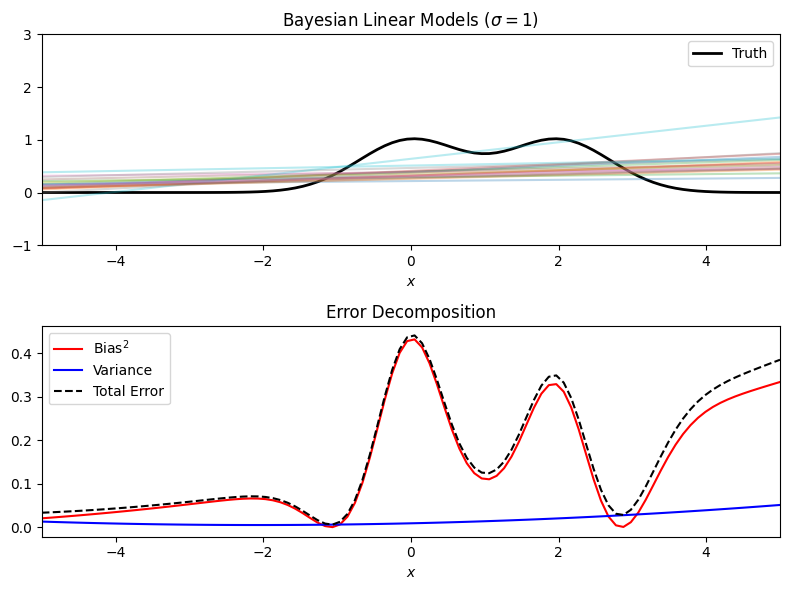

In [ ]:
def bayesian_linear_predict(xs_train, ys_train, xs_test, prior_sigma, noise_sigma=0.25):
    X = np.column_stack([np.ones_like(xs_train), xs_train])
    X_test = np.column_stack([np.ones_like(xs_test), xs_test])
    prior_precision = 1.0 / prior_sigma**2
    noise_precision = 1.0 / noise_sigma**2
    posterior_precision = (noise_precision * X.T @ X + prior_precision * np.eye(X.shape[1]))
    posterior_cov = np.linalg.inv(posterior_precision)
    posterior_mean = (posterior_cov @ (noise_precision * X.T @ ys_train))
    return X_test @ posterior_mean

def show_bias_variance_by_sigma(sigma, noise_sigma=0.25):
    all_preds = []
    plt.figure(figsize=(8, 6))
    for i in range(n_models):
        xs_model, ys_model = sample_data_sets[i]
        ys_pred = bayesian_linear_predict(xs_model, ys_model, xs_truth, sigma, noise_sigma)
        all_preds.append(ys_pred)
    all_preds = np.array(all_preds)
    avg_pred = np.mean(all_preds, axis=0)
    bias_sq = (avg_pred - ys_truth)**2
    variance = np.var(all_preds, axis=0)
    total_error = bias_sq + variance

    plt.subplot(2, 1, 1)
    plt.plot(xs_truth, ys_truth, label="Truth", color="black", linewidth=2)
    for i in range(n_models):
        plt.plot(xs_truth, all_preds[i], alpha=0.3)
    plt.title(f"Bayesian Linear Models ($\\sigma={sigma}$)")
    plt.legend()
    plt.xlabel("$x$")
    plt.xlim(xs_truth.min(), xs_truth.max())
    plt.ylim(-1, 3)

    plt.subplot(2, 1, 2)
    plt.plot(xs_truth, bias_sq, color="red", label="Bias$^2$")
    plt.plot(xs_truth, variance, color="blue", label="Variance")
    plt.plot(xs_truth, total_error, color="black", linestyle="--", label="Total Error")
    plt.title("Error Decomposition")
    plt.legend()
    plt.xlabel("$x$")
    plt.xlim(xs_truth.min(), xs_truth.max())
    plt.tight_layout()
    plt.show()

show_bias_variance_by_sigma(1)

Script:
* Here is a Bayesian linear regression using a prior with standard deviations of 1 for each parameter.
* It doesn't change the model much since both parameters were small without the prior.

## Multivariate Normal Prior ($\sigma=0.01$)


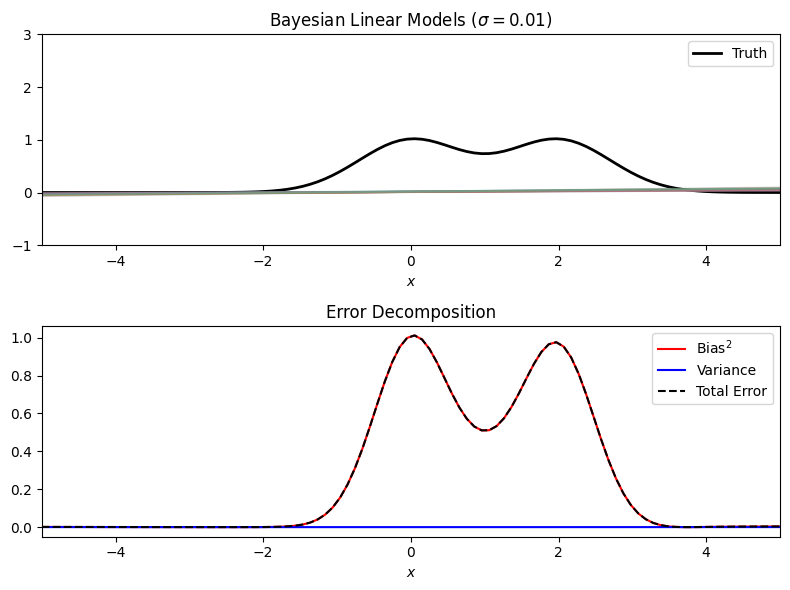

In [ ]:
show_bias_variance_by_sigma(0.01)

Script:
* These models use 1/100 for the prior standard deviations.
* This is a very strong prior saying that the parameters are almost always going to be very close to zero.
* We can see this in all the resulting models being close to $y=0$.
* This is fine for the ends where the function is close to zero, but it does a poor job in the middle where the values are far from zero.
* This prior is just too strong for this problem.

## Bias and Variance by $\sigma$


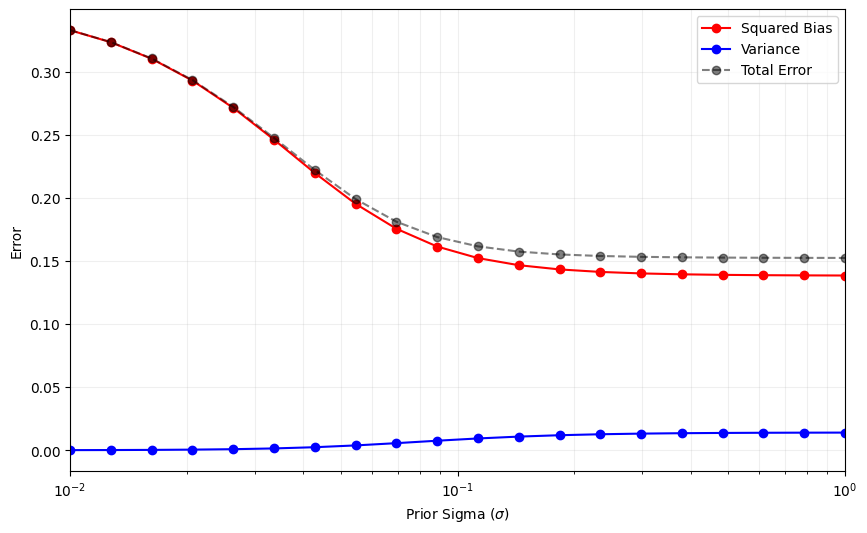

In [ ]:
sigmas = np.geomspace(0.01, 1, 20)

avg_sq_biases_bayesian = []
avg_variances_bayesian = []

for s in sigmas:
    all_preds = []
    for i in range(n_models):
        xs_model, ys_model = sample_data_sets[i]
        ys_pred = bayesian_linear_predict(xs_model, ys_model, xs_truth, s)
        all_preds.append(ys_pred)

    all_preds = np.array(all_preds)
    avg_pred = np.mean(all_preds, axis=0)
    bias_sq = (avg_pred - ys_truth)**2
    variance = np.var(all_preds, axis=0)

    # Average over the central range of x to avoid boundary artifacts
    avg_sq_biases_bayesian.append(np.mean(bias_sq[10:90]))
    avg_variances_bayesian.append(np.mean(variance[10:90]))

plt.figure(figsize=(10, 6))
plt.plot(sigmas, avg_sq_biases_bayesian, 'o-', label='Squared Bias', color='red')
plt.plot(sigmas, avg_variances_bayesian, 'o-', label='Variance', color='blue')
plt.plot(sigmas, np.array(avg_sq_biases_bayesian) + np.array(avg_variances_bayesian), 'o--', label='Total Error', color='black', alpha=0.5)

plt.xscale('log')
plt.xlabel(r'Prior Sigma ($\sigma$)')
plt.xlim(sigmas.min(), sigmas.max())
plt.ylabel('Error')
# plt.title('Bias-Variance Tradeoff by Prior Strength (Bayesian Linear Model)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Script:
* This chart shows the tradeoff as the prior standard deviation, $\sigma$, changes.
* When $\sigma$ is 1/100, then bias is high, but it drops as $\sigma$ increases and allows the model to fit more closely.
* At the same time, the variance starts very low since the prior suppresses variation in the models, and it increases as $\sigma$ increases and the model predictions change more.
* In this case, the squared bias is much higher overall, so it drives the total error trend.
* Note that in this case, the same functional form is being used so the number of parameters isn't changing despite the bias and variance changing.

Script: (faculty on screen)
* Bias and variance often correlate with model flexibility and the model parameters, but the real story is more complicated.
* Bias and variance really are driven by how the modeling process reacts or does not react to variation in the training data.